# Automatic bandwidth selection with `correlogram_range` and `knn_range`

`LocalBootstrap` and `LocalPermutation` both require the user to supply a
*bandwidth* or *threshold* that controls how local the resampling is.  Choosing
this value by hand is awkward.

`spml` provides two helper functions that estimate the **range of spatial
autocorrelation** — the distance (or neighbour order) beyond which observations
are no longer correlated — and return it as a ready-to-use bandwidth.

| Function | Returns | Use as |
|---|---|---|
| `correlogram_range` | distance (float) | `LocalBootstrap(bandwidth=...)`, `LocalPermutation(threshold=...)` |
| `knn_range` | neighbour order (int) | build a KNN graph, pass as `LocalBootstrap(graph=...)` |

In [1]:
import geodatasets
import geopandas
import numpy
import seaborn
import colormaps
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from libpysal.graph import Graph


from spml.validation import (
    correlogram_range,
    knn_range,
    LocalBootstrap,
    LocalPermutation,
)

chicago = (
    geopandas.read_file(geodatasets.get_path("geoda.chicago_health"))
    .to_crs("EPSG:32616")
)
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())

y = chicago["income"].to_numpy()
print(f"{len(chicago)} community areas")
print(f"income range: ${y.min():,.0f} – ${y.max():,.0f}")

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


77 community areas
income range: $14,905 – $2,075,859


## 1  Visualising spatial autocorrelation

Before estimating the range, it helps to see the variable mapped — a strongly
clustered pattern suggests high spatial autocorrelation and a larger range.

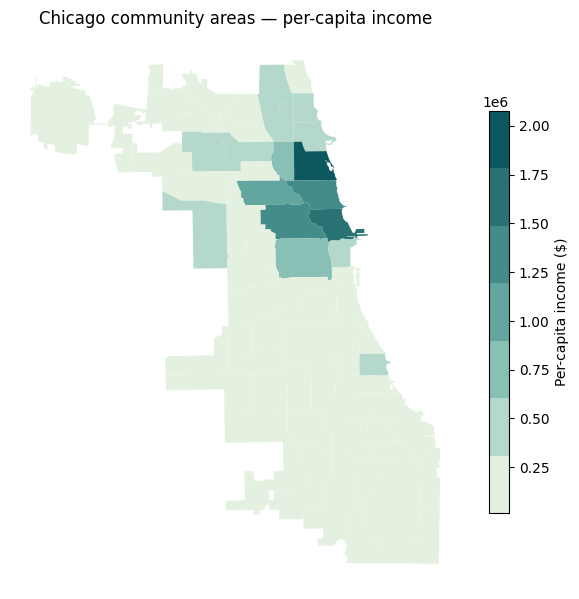

In [2]:
fig, ax = plt.subplots(figsize=(6, 7))
chicago.plot(
    column="income",
    cmap=colormaps.mint,
    legend=True,
    legend_kwds={"label": "Per-capita income ($)", "shrink": 0.6},
    ax=ax,
)
ax.set_axis_off()
ax.set_title("Chicago community areas — per-capita income", pad=8)
fig.tight_layout()
plt.show()

## 2  Distance correlogram  (`correlogram_range`)

The **spatial correlogram** is the average normalised cross-product
$(y_i - \bar y)(y_j - \bar y)/\sigma^2$ between all pairs of observations
at each distance lag.  It starts near 1 for very close pairs and decays toward
0 (or below) as distance increases.

`correlogram_range` bins all pairwise distances, computes the mean correlation
in each bin, then interpolates the **first zero crossing**.  That crossing is
the estimated range — the bandwidth at which nearby observations stop being
more similar than average.

Estimated range: 8.38 km


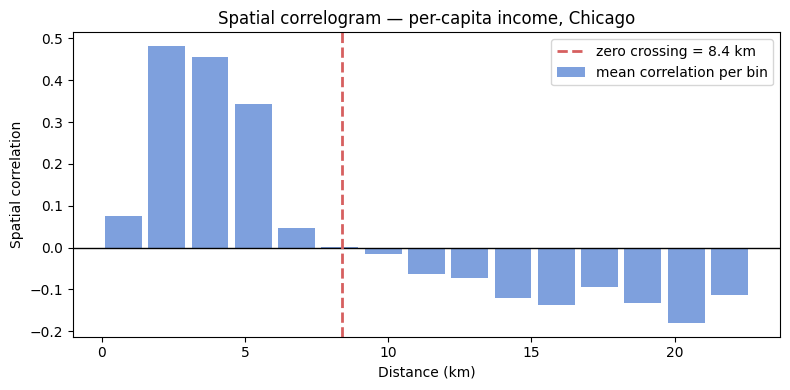

In [3]:
# ── Re-implement the binning so we can plot it ────────────────────────────────

coords = numpy.column_stack([
    chicago.geometry.centroid.x,
    chicago.geometry.centroid.y,
])
y_z = (y - y.mean()) / y.std()

dists = pdist(coords)
n = len(coords)
iu = numpy.triu_indices(n, k=1)
prods = numpy.outer(y_z, y_z)[iu]

MAX_DIST = dists.max() / 2
N_BINS = 15
bins = numpy.linspace(0, MAX_DIST, N_BINS + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_corrs = numpy.full(N_BINS, numpy.nan)

for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mask = (dists >= lo) & (dists < hi)
    if mask.sum() >= 2:
        bin_corrs[k] = float(prods[mask].mean())

# ── Estimate range ────────────────────────────────────────────────────────────
d_range = correlogram_range(chicago, y, random_state=0)
print(f"Estimated range: {d_range/1000:.2f} km")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_centers / 1000, bin_corrs, width=(MAX_DIST / N_BINS / 1000) * 0.85,
       color="#4878cf", alpha=0.7, label="mean correlation per bin")
ax.axhline(0, color="black", lw=1)
ax.axvline(d_range / 1000, color="#d65f5f", lw=2, ls="--",
           label=f"zero crossing = {d_range/1000:.1f} km")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Spatial correlation")
ax.set_title("Spatial correlogram — per-capita income, Chicago")
ax.legend()
fig.tight_layout()
plt.show()

## 3  KNN lag correlation  (`knn_range`)

Instead of binning by distance, `knn_range` steps through neighbour orders
$k = 1, 2, \ldots$ and at each step computes the Pearson correlation between
$y$ and its $k$-nearest-neighbour spatial lag
$\bar y_i^{(k)} = \frac{1}{k}\sum_{j \in \text{kNN}(i)} y_j$.

It returns the last $k$ for which this correlation is still positive — the
number of neighbours to include before information becomes irrelevant.

Estimated k range: 62 nearest neighbours


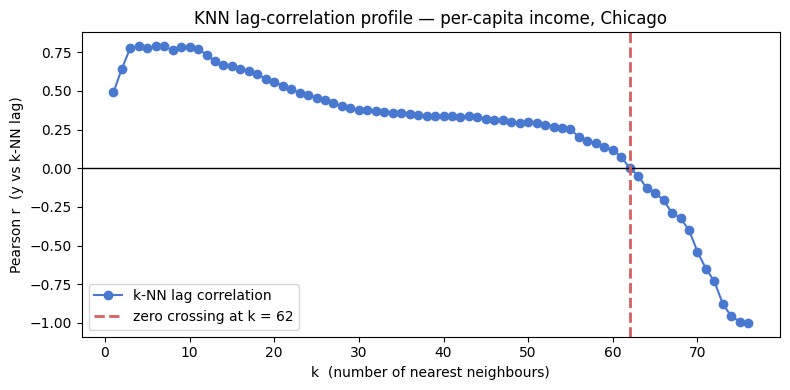

In [4]:
from scipy.spatial import cKDTree

tree = cKDTree(coords)
MAX_K = len(chicago) - 1
_, all_idx = tree.query(coords, k=MAX_K + 1)
all_idx = all_idx[:, 1:]  # drop self

ks = list(range(1, MAX_K + 1))
lag_corrs = []
for k in ks:
    lag = y_z[all_idx[:, :k]].mean(axis=1)
    lag_corrs.append(float(numpy.corrcoef(y_z, lag)[0, 1]))

k_range = knn_range(chicago, y, max_k=MAX_K)
if k_range == MAX_K:
    print("Note: correlation did not cross zero — using max_k as upper bound.")
print(f"Estimated k range: {k_range} nearest neighbours")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, lag_corrs, "o-", color="#4878cf", ms=6, label="k-NN lag correlation")
ax.axhline(0, color="black", lw=1)
ax.axvline(k_range, color="#d65f5f", lw=2, ls="--",
           label=f"zero crossing at k = {k_range}")
ax.set_xlabel("k  (number of nearest neighbours)")
ax.set_ylabel("Pearson r  (y vs k-NN lag)")
ax.set_title("KNN lag-correlation profile — per-capita income, Chicago")
ax.legend()
fig.tight_layout()
plt.show()

## 4  Using the range in `LocalBootstrap`

Pass `d_range` directly as `bandwidth`.  The bootstrap will draw each
replacement observation from within the autocorrelation range, so the
resampled dataset has the same spatial structure as the original.

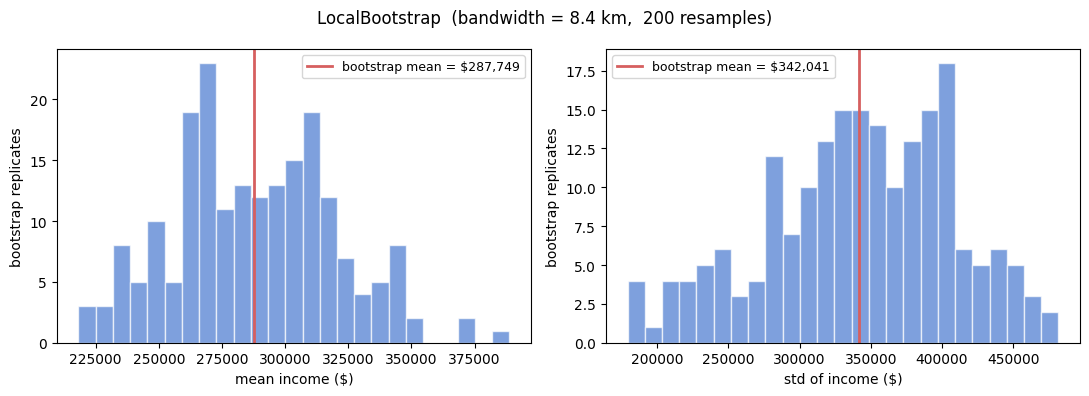

In [5]:
lb = LocalBootstrap(
    bandwidth=d_range,
    kernel="bisquare",
    n_bootstraps=200,
    random_state=0,
)

# Collect bootstrap distributions of the income mean and std
boot_means = []
boot_stds  = []
for idx in lb.sample(chicago):
    boot_means.append(chicago.loc[idx, "income"].mean())
    boot_stds.append(chicago.loc[idx, "income"].std())
    

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, vals, stat in zip(
    axes,
    [boot_means, boot_stds],
    ["mean income ($)", "std of income ($)"],
):
    ax.hist(vals, bins=25, color="#4878cf", alpha=0.7, edgecolor="white")
    ax.axvline(numpy.mean(vals), color="#d65f5f", lw=2,
               label=f"bootstrap mean = ${numpy.mean(vals):,.0f}")
    ax.set_xlabel(stat)
    ax.set_ylabel("bootstrap replicates")
    ax.legend(fontsize=9)

fig.suptitle(
    f"LocalBootstrap  (bandwidth = {d_range/1000:.1f} km,  200 resamples)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## 5  Using the range in `LocalPermutation`

`d_range` is equally valid as the `threshold` for `LocalPermutation`.
Each observation is swapped only with observations within the autocorrelation
range, preserving large-scale spatial structure while shuffling local patterns.

To show the permutation is local, we plot the **displacement** of each
community area (how far its assigned source is from its original location).

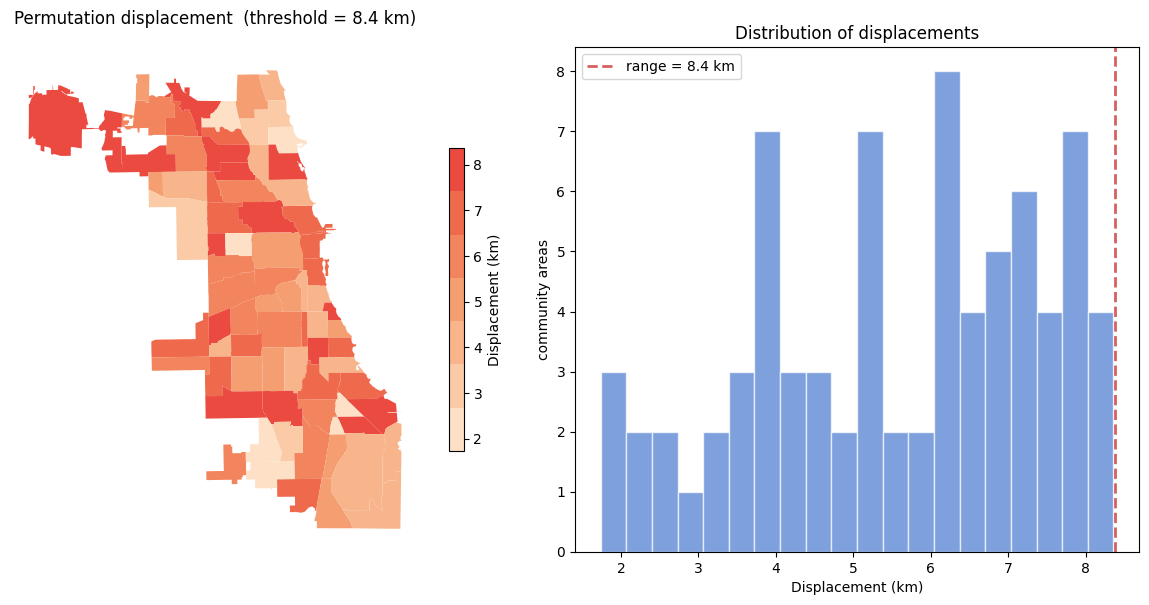

Max displacement: 8.4 km
Mean displacement: 5.6 km
Range threshold: 8.4 km


In [6]:
lp = LocalPermutation(
    bandwidth=d_range,
    n_permutations=1,
    random_state=0,
)
perm_idx = next(lp.sample(chicago))

# Displacement = distance from each area to its source area
centroids = numpy.column_stack([
    chicago.geometry.centroid.x,
    chicago.geometry.centroid.y,
])
pos_map = {label: i for i, label in enumerate(chicago.index)}
src_pos = numpy.array([pos_map[label] for label in perm_idx])
displacements = numpy.sqrt(
    ((centroids - centroids[src_pos]) ** 2).sum(axis=1)
) / 1000  # km

chicago_disp = chicago.copy()
chicago_disp["displacement_km"] = displacements

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

chicago_disp.plot(
    column="displacement_km",
    cmap=colormaps.peach,
    legend=True,
    legend_kwds={"label": "Displacement (km)", "shrink": 0.6},
    ax=axes[0],
)
axes[0].set_axis_off()
axes[0].set_title(
    f"Permutation displacement  (threshold = {d_range/1000:.1f} km)"
)

axes[1].hist(displacements, bins=20, color="#4878cf",
             alpha=0.7, edgecolor="white")
axes[1].axvline(d_range / 1000, color="#d65f5f", lw=2, ls="--",
                label=f"range = {d_range/1000:.1f} km")
axes[1].set_xlabel("Displacement (km)")
axes[1].set_ylabel("community areas")
axes[1].set_title("Distribution of displacements")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"Max displacement: {displacements.max():.1f} km")
print(f"Mean displacement: {displacements.mean():.1f} km")
print(f"Range threshold: {d_range/1000:.1f} km")

You can see that as the permutation gets "larger", the autocorrelation of the synthetic dataset goes down. Thus, more "realistic" random datasets are obtained with small shuffles. 

In [7]:
from esda import Moran
# build_knn requires Point geometry
chicago_pts = chicago.copy()
chicago_pts["geometry"] = chicago.geometry.centroid

base_graph = Graph.build_knn(chicago_pts, k=5)
real_moran_knn = Moran(chicago.income, base_graph)

lps = numpy.empty((4, 99))

for i, k in enumerate((5,15,50)):
    lp = LocalPermutation(
        graph=Graph.build_knn(chicago_pts, k=k),
        derangement=False,
        n_permutations=99,
        n_burn=10,
    )
    for p, perm_idxs in enumerate(lp.sample(chicago)):
        chicago_ = chicago.copy()
        chicago_["income"] = chicago.loc[perm_idxs, "income"].values
        lps[i, p] = Moran(chicago_.income, w=base_graph).I
        if i == 1:
            chicago_pts_ = chicago_pts.sample(frac=1, replace=False)
            chicago_pts_.index = chicago_pts.index
            lps[-1, p] = Moran(
                chicago_.income,
                Graph.build_knn(chicago_pts_, k=5),
                permutations=0,
            ).I

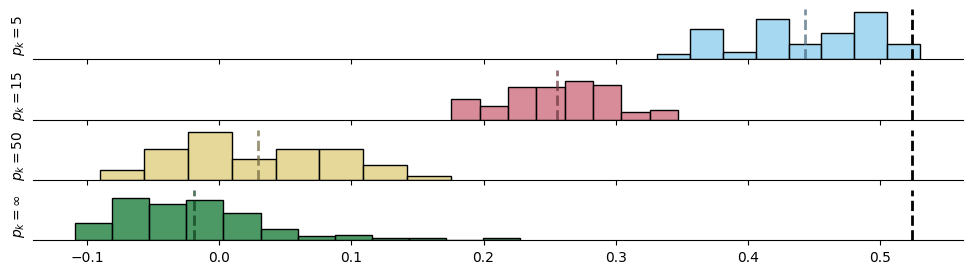

In [8]:
f,ax = plt.subplots(4,1, figsize=(12,3), sharey=True, sharex=True)
seaborn.set_palette(colormaps.safe[:4].colors)
for i,m in enumerate(lps.mean(axis=1)):
    seaborn.histplot(
    lps[i,:],
    color=colormaps.safe[:4].colors[i],
    fill=True,
    ax=ax[i]
    ) 
    ax[i].axvline(
        m, color=colormaps.safe[:4].colors[i]*.5, linewidth=2, linestyle='--',alpha=.7
    )
    ax[i].tick_params(left=False, labelleft=False)
    ax[i].axvline(real_moran_knn.I, color='k', alpha=1, linewidth=2, linestyle='--', label=f'real = {real_moran_knn.I:.2f}')
    ax[i].set_ylabel(['$p_k=5$', '$p_k=15$', '$p_k=50$', '$p_k=\infty$'][i])
    seaborn.despine(left=True)
plt.show()

## 6  Automatic bandwidth selection with `bandwidth='auto'`

Rather than computing the range manually and passing it in, both
`LocalBootstrap` and `LocalPermutation` accept `bandwidth='auto'`
(or `k='auto'`).  When set to `'auto'`, you must call `fit(X, y)`
first -- this runs `correlogram_range` (for bandwidth) or `knn_range`
(for k) internally and stores the result as `bandwidth_` or `k_`.
Calling `sample()` without `fit()` when using `'auto'` raises a
`NotFittedError`.

In [9]:
from sklearn.exceptions import NotFittedError
from spml.validation import LocalBootstrap, LocalPermutation

# bandwidth='auto' raises NotFittedError if sample() is called without fit()
try:
    list(LocalBootstrap(bandwidth='auto', n_bootstraps=1).sample(chicago))
except NotFittedError as e:
    print('NotFittedError:', e)

NotFittedError: This LocalBootstrap instance has bandwidth='auto' but fit() has not been called. Call fit(X, y) first.


### `LocalBootstrap` with `bandwidth='auto'`

`fit(X, y)` runs `correlogram_range` and stores the result as
`bandwidth_`.  `sample()` then uses that bandwidth without any extra
arguments.  The two steps can be chained.

Auto-selected bandwidth: 8379 m


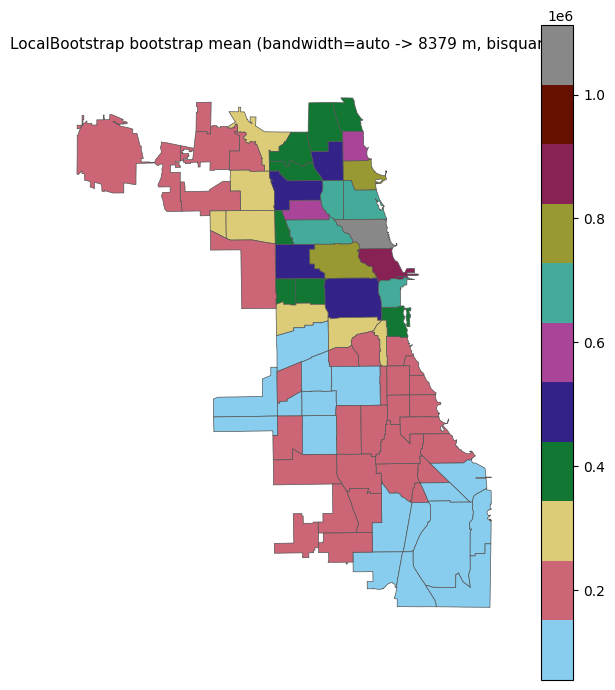

In [10]:
lb_auto = LocalBootstrap(
    bandwidth="auto",
    kernel="bisquare",
    n_bootstraps=200,
    random_state=0,
)
lb_auto.fit(chicago, chicago.income.values)
print(f"Auto-selected bandwidth: {lb_auto.bandwidth_:.0f} m")

boot_mean = numpy.zeros(len(chicago))
for indices in lb_auto.sample(chicago):
    boot_mean += chicago.income.values[chicago.index.get_indexer(indices)]
boot_mean /= lb_auto.n_bootstraps

fig, ax = plt.subplots(figsize=(6, 7))
chicago.assign(_v=boot_mean).plot(
    column="_v", cmap=colormaps.safe, legend=True, ax=ax,
    edgecolor="#555", linewidth=0.5,
)
ax.set_title(
    f"LocalBootstrap bootstrap mean (bandwidth=auto -> {lb_auto.bandwidth_:.0f} m, bisquare)",
    fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

### `LocalPermutation` with `k='auto'`

`k='auto'` calls `knn_range` in `fit()` and stores the result as
`k_`.  The chained form `lp.fit(chicago, y).sample(chicago)` is the
most concise way to use it.

Auto-selected k: 30


/Users/lw17329/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_local_permutation.py:148: UserWarning: knn_range: correlation did not drop to zero within max_k=30. Consider increasing max_k. Returning max_k.
  k = knn_range(X, y)


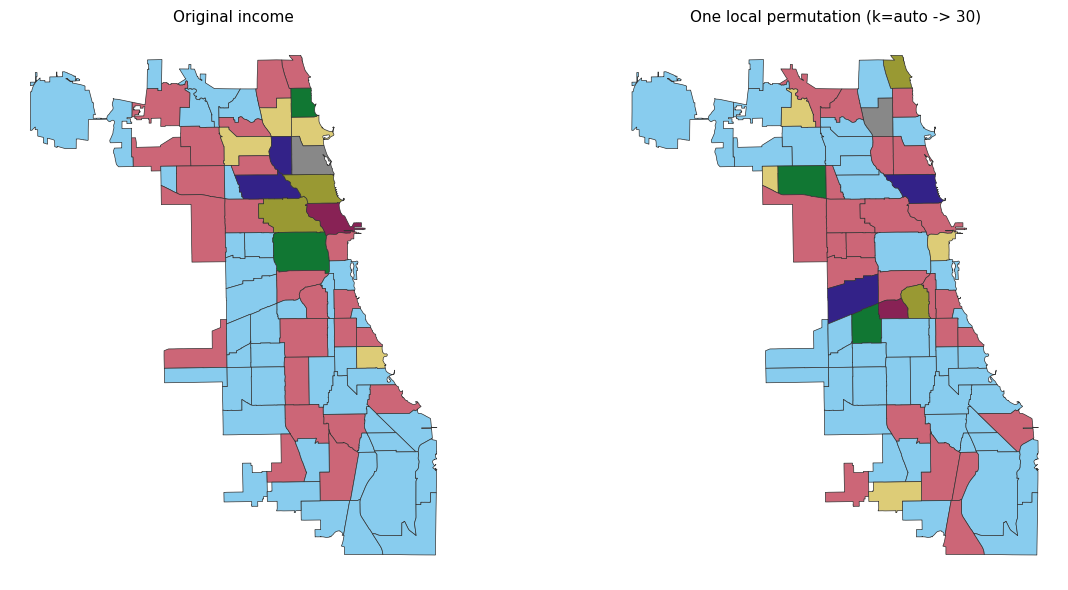

In [11]:
lp_auto = LocalPermutation(
    k="auto",
    kernel="bisquare",
    n_permutations=1,
    random_state=0,
)
lp_auto.fit(chicago, chicago.income.values)
print(f"Auto-selected k: {lp_auto.k_}")

perm = next(lp_auto.sample(chicago))
y_perm = chicago.income.values[chicago.index.get_indexer(perm)]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
kw = dict(cmap=colormaps.safe, edgecolor="#333", linewidth=0.5, legend=False)
chicago.assign(_v=chicago.income.values).plot(column="_v", ax=axes[0], **kw)
axes[0].set_title("Original income", fontsize=11)
axes[0].axis("off")
chicago.assign(_v=y_perm).plot(column="_v", ax=axes[1], **kw)
axes[1].set_title(f"One local permutation (k=auto -> {lp_auto.k_})", fontsize=11)
axes[1].axis("off")
plt.tight_layout()
plt.show()